In [ ]:
pip install openpyxl

In [ ]:
pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 23.9 MB/s eta 0:00:00


In [ ]:
!pip install gensim

In [ ]:
#데이터 불러오기
import pandas as pd

df = pd.read_excel("/content/review_ft.xlsx") # 뉴스 데이터 읽기
df.head()

,공연코드,평점,리뷰수,인지도,장르,시놉시스
0,PF421000,9.66,239.0,7,"가족,아동",말괄량이 삐삐가 원숭이 닐슨과 조랑말 한스 그리고 금화가 가득 든 가방을 들고 삐삐...
1,PF421016,9.54,645.0,59,라이선스 뮤지컬,가난한 소녀 크리스틴과 파리 오페라 하우스에서 일하는 신인 가수로서 성공을 꿈꾸는 ...
2,PF421083,9.40,2218.0,13,창작뮤지컬,모든 것을 갖춰야만 입학할 수 있는 최고의 명문 학교 ‘브릭스턴 아카데미’. 절친한...
3,PF421085,8.20,1377.0,49,창작뮤지컬,"전쟁 중에 돈을 벌 수 있는 유일한 직업이라는 이유로 군인이 된 가난한 남자, 보이..."
4,PF421176,10.00,6.0,33,창작뮤지컬,올해의 인플루언서상을 받는 인별. 하지만 진짜 이름인 복자와 IS인별로 살아가는 삶...


In [ ]:
len(df)

348

In [ ]:
df.dtypes

,0
공연코드,object
평점,float64
리뷰수,float64
인지도,int64
장르,object
시놉시스,object


#장르 합치기

In [ ]:
df['장르'].unique()

array(['창작뮤지컬', '로맨스극', '코미디극', '드라마극'], dtype=object)

In [ ]:
# 장르를 분류하고 이름을 변경하는 함수
def 장르_분류(장르):
    if 장르 == '뮤지컬':
        return '창작뮤지컬'  # 일반 '뮤지컬'을 '창작뮤지컬'로 매핑
    elif 장르 == '연극':
        return '드라마극'  # 일반 '연극'을 '드라마극'으로 매핑
    elif 장르 == '오리지널 내한공연':
        return '내한공연'  # '내한공연'으로 매핑
    else:
        return 장르  # 다른 모든 장르는 원래 이름 유지

# 데이터프레임의 '장르' 열에 함수를 적용하여 변경된 값을 새로운 열에 저장
df['장르'] = df['장르'].apply(장르_분류)

# 결과 출력
df[['공연코드', '장르']].head()

,공연코드,장르
0,PF421000,"가족,아동"
1,PF421016,라이선스 뮤지컬
2,PF421083,창작뮤지컬
3,PF421085,창작뮤지컬
4,PF421176,창작뮤지컬


#LDA과정

In [ ]:
# stopword.txt 파일을 로드하여 불용어 리스트 형식으로 변환하는 코드입니다.
stopword_file_path = '/content/stopword.txt'

# Load the stopword list.
with open(stopword_file_path, 'r', encoding='utf-8') as file:
    stopwords = file.read().splitlines()

# Additional stopwords to be added
additional_stopwords = []

# Add the additional stopwords to the list
stopwords.extend(additional_stopwords)

# Check the result
print(stopwords[:10])  # Print and check the first 10 stopwords.


['않다', '되어다', '되다', '하다', '어떻다', '이렇다', '이다', '어제', '매일', '아']


#일단 합쳐서 돌려본 코드

In [ ]:
# 시놉시스 컬럼의 데이터 타입을 확인
print(df['시놉시스'].apply(type).value_counts())

# 만약 문자열이 아닌 데이터가 있다면, 이를 문자열로 변환
df['시놉시스'] = df['시놉시스'].astype(str)

시놉시스
<class 'str'>      339
<class 'float'>      9
Name: count, dtype: int64


In [ ]:
import gensim
from sklearn.feature_extraction.text import CountVectorizer
from konlpy.tag import Okt
import re

twit = Okt()

def my_tokenizer(text):
    # 한글, 영문 및 공백을 제외한 모든 문자 제거
    text = re.sub(r'[^가-힣A-Za-z\s]', '', text)
    # 품사 태깅 후, 명사, 동사, 형용사 중 불용어가 아닌 단어만 선택
    return [token for token, pos in twit.pos(text) if pos in ['Noun', 'Adjective'] and token not in stopwords]

# 첫 번째 문서에 대한 토크나이저 결과 확인
print("토크나이저 결과:", my_tokenizer(df.시놉시스[0]))

# 전체 텍스트에 대한 토크나이저 적용
texts = [my_tokenizer(news) for news in df.시놉시스]

토크나이저 결과: ['런던', '외곽', '위치', '낡고', '오래된', '레코드', '샵', '주인', '존', '오늘', '하루', '활기차게', '시작', '세계', '일주', '찰리', '오디션', '스칼렛', '레코드', '꿈', '대한', '이야기']


In [ ]:
from gensim.corpora.dictionary import Dictionary

# 토큰화 결과로부터 dictionay 생성
dictionary = Dictionary(texts)
print('#Number of initial unique words in documents:', len(dictionary))

# 문서 빈도수가 너무 적거나 높은 단어를 필터링하고 특성을 단어의 빈도 순으로 선택
dictionary.filter_extremes(keep_n=2000, no_below=5, no_above=0.8)
print('#Number of unique words after removing rare and common words:', len(dictionary))

# 카운트 벡터로 변환
corpus = [dictionary.doc2bow(text) for text in texts]
print('#Number of unique tokens: %d' % len(dictionary))
print('#Number of documents: %d' % len(corpus))

#Number of initial unique words in documents: 272
#Number of unique words after removing rare and common words: 0
#Number of unique tokens: 0
#Number of documents: 9


In [ ]:
vec = CountVectorizer(tokenizer=my_tokenizer,
                      max_df=0.8, min_df=5,
                      max_features=2000)

# df1.content에 대해서 CountVectorizer 적용
# 여기서 df1은 이미 데이터프레임이 정의되어 있어야 하며, 'content' 컬럼에 분석할 텍스트 데이터가 포함되어 있어야 합니다.
pet_cv = vec.fit_transform(df['시놉시스'])
print(pet_cv.shape)

(348, 515)


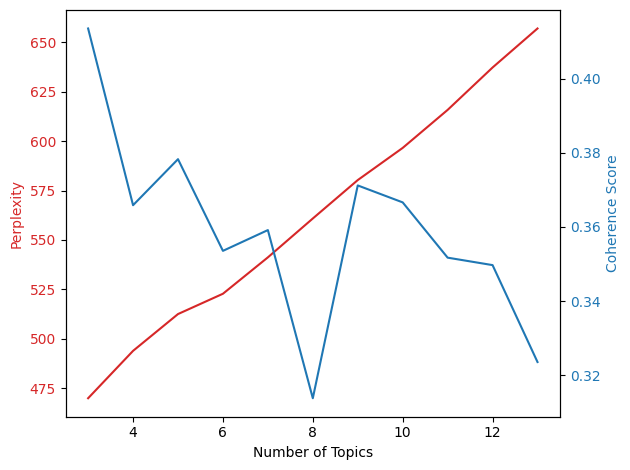

Minimum Perplexity: 470.05368589346267 at 3
Maximum Coherence Score: 0.41353172458953963 at 3


In [ ]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel
from gensim.corpora.dictionary import Dictionary
from gensim import matutils
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def compute_metrics(vec, dictionary, corpus, texts, start=3, end=13, max_iter=5, topic_word_prior=0.1, doc_topic_prior=1.0, step=1):
    iter_num = range(start, end + 1, step)
    per_values = []
    co_values = []

    for i in iter_num:
        # Perplexity 계산
        lda = LatentDirichletAllocation(n_components=i, max_iter=max_iter, topic_word_prior=topic_word_prior, doc_topic_prior=doc_topic_prior, learning_method='batch', n_jobs=-1, random_state=7)
        lda.fit(vec)
        per_values.append(lda.perplexity(vec))

        # Coherence Score 계산
        model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=i)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        co_values.append(coherencemodel.get_coherence())

    # 그래프 그리기
    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.set_xlabel('Number of Topics')
    ax1.set_ylabel('Perplexity', color=color)
    ax1.plot(iter_num, per_values, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Coherence Score', color=color)
    ax2.plot(iter_num, co_values, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.show()

    # 최적의 토픽 수와 해당 값 출력
    min_per_index = per_values.index(min(per_values))
    max_co_index = co_values.index(max(co_values))
    print("Minimum Perplexity:", min(per_values), "at", start + min_per_index * step)
    print("Maximum Coherence Score:", max(co_values), "at", start + max_co_index * step)

# 함수 실행
compute_metrics(pet_cv, dictionary, corpus, texts, start=3, end=13)

In [ ]:
from gensim.models import LdaModel

num_topics = 3 #토픽의 수

ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = num_topics, id2word=dictionary, passes=20)
#passes=6 -> 알고리즘 반복 횟수 6번

In [ ]:
#토픽의 비중을 단어와 함께 출력

for topic in ldamodel.print_topics():
    print(topic)

(0, '0.027*"수" + 0.020*"사람" + 0.017*"있는" + 0.014*"속" + 0.013*"이야기" + 0.013*"시작" + 0.012*"위해" + 0.012*"삶" + 0.010*"없는" + 0.009*"친구"')
(1, '0.025*"사랑" + 0.018*"그녀" + 0.016*"연극" + 0.015*"가족" + 0.012*"남편" + 0.011*"집" + 0.011*"주인공" + 0.011*"날" + 0.010*"딸" + 0.010*"돈"')
(2, '0.017*"위해" + 0.017*"사람" + 0.012*"시작" + 0.012*"있는" + 0.012*"친구" + 0.012*"엄마" + 0.011*"전" + 0.010*"세상" + 0.010*"저택" + 0.010*"기억"')


#장르별로 나누어서 따로 돌려본 코드
(근데 최적토픽수 시각화 그림은 뭔가 걍 합친거 쓰는게 좋아보여서 구라친거긴합니다.ㅎ)

In [ ]:
import gensim
from sklearn.feature_extraction.text import CountVectorizer
from konlpy.tag import Okt
import re

# 토크나이저 함수 정의
def my_tokenizer(text):
    # 한글, 영문 및 공백을 제외한 모든 문자 제거
    text = re.sub(r'[^가-힣A-Za-z\s]', '', text)
    # 품사 태깅 후, 명사와 형용사 중 불용어가 아닌 단어만 선택
    return [token for token, pos in twit.pos(text) if pos in ['Noun', 'Adjective'] and token not in stopwords]

# 장르별로 데이터를 분리하고 사전 준비 작업 수행
genre_texts = {}

for genre in df['장르'].unique():
    print(f"\n--- {genre} ---")

    # 해당 장르의 시놉시스 텍스트 선택
    genre_df = df[df['장르'] == genre]

    # 장르에 속한 모든 텍스트에 대해 토크나이저 적용
    texts = [my_tokenizer(news) for news in genre_df['시놉시스']]

    # 토큰화 결과로부터 Dictionary 생성
    dictionary = Dictionary(texts)
    print('#Number of initial unique words in documents:', len(dictionary))

    # 문서 빈도수가 너무 적거나 높은 단어를 필터링하고 특성을 단어의 빈도 순으로 선택
    dictionary.filter_extremes(keep_n=2000, no_below=5, no_above=0.8)
    print('#Number of unique words after removing rare and common words:', len(dictionary))

    # 장르별 텍스트와 사전을 저장
    genre_texts[genre] = {
        'texts': texts,
        'dictionary': dictionary
    }


--- 가족,아동 ---
#Number of initial unique words in documents: 568
#Number of unique words after removing rare and common words: 14

--- 라이선스 뮤지컬 ---
#Number of initial unique words in documents: 348
#Number of unique words after removing rare and common words: 2

--- 창작뮤지컬 ---
#Number of initial unique words in documents: 2372
#Number of unique words after removing rare and common words: 128

--- 드라마극 ---
#Number of initial unique words in documents: 3236
#Number of unique words after removing rare and common words: 227

--- 내한공연 ---
#Number of initial unique words in documents: 120
#Number of unique words after removing rare and common words: 0

--- 로맨스극 ---
#Number of initial unique words in documents: 405
#Number of unique words after removing rare and common words: 6

--- 넌버벌퍼포먼스 ---
#Number of initial unique words in documents: 18
#Number of unique words after removing rare and common words: 0

--- 공포극 ---
#Number of initial unique words in documents: 104
#Number of unique words af

In [ ]:
from gensim.models import CoherenceModel
import gensim
import numpy as np

# 최적의 토픽 수를 찾는 함수
def find_optimal_topics(dictionary, corpus, texts, start=2, end=8, step=1):
    coherence_values = []
    model_list = []

    for num_topics in range(start, end + 1, step):
        model = gensim.models.LdaModel(corpus=corpus,
                                       id2word=dictionary,
                                       num_topics=num_topics,
                                       passes=10,
                                       random_state=42)
        model_list.append(model)

        # 토픽 일관성 계산
        coherence_model = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())

    # 최적 토픽 수
    optimal_num_topics = range(start, end + 1, step)[np.argmax(coherence_values)]

    return optimal_num_topics, model_list[np.argmax(coherence_values)], coherence_values

# 장르별 최적의 토픽 수 찾기 및 LDA 모델 학습
optimal_topics_per_genre = {}

for genre, data in genre_texts.items():
    print(f"\n--- {genre} ---")

    texts = data['texts']
    dictionary = data['dictionary']
    corpus = [dictionary.doc2bow(text) for text in texts]

    # 비어있는 코퍼스 확인 및 처리
    if not corpus or all(len(doc) == 0 for doc in corpus):
        print(f"'{genre}' 장르는 단어가 부족하여 LDA 모델을 학습할 수 없습니다.")
        continue

    # 최적의 토픽 수 찾기
    optimal_num_topics, optimal_model, coherence_values = find_optimal_topics(dictionary, corpus, texts, start=2, end=8, step=1)

    # 최적의 토픽 수가 5개 이상이면 5개로 제한
    if optimal_num_topics > 5:
        optimal_num_topics = 5

    # 5개의 토픽 수로 LDA 모델 재학습
    lda_model = gensim.models.LdaModel(corpus=corpus,
                                       id2word=dictionary,
                                       num_topics=optimal_num_topics,
                                       passes=10,
                                       random_state=42)

    # 결과 저장
    optimal_topics_per_genre[genre] = {
        'optimal_num_topics': optimal_num_topics,
        'optimal_model': lda_model,
        'coherence_values': coherence_values
    }

    print(f"Final number of topics for {genre}: {optimal_num_topics}")

    # LDA 결과 출력
    print("\nLDA Topics:")
    for idx, topic in lda_model.show_topics(formatted=False):
        print(f"Topic {idx}: {[word for word, prob in topic]}")

# 최종 결과 출력
for genre, result in optimal_topics_per_genre.items():
    print(f"\n{genre}: Number of topics used = {result['optimal_num_topics']}")
    print(f"Coherence values: {result['coherence_values']}")



--- 가족,아동 ---
Final number of topics for 가족,아동: 3

LDA Topics:
Topic 0: ['엄마', '위해', '시작', '마을', '친구', '입니다', '마법', '집', '날', '이야기']
Topic 1: ['있는', '집', '친구', '엄마', '속', '마법', '위해', '입니다', '이야기', '아름다운']
Topic 2: ['수', '속', '이야기', '아름다운', '날', '마법', '입니다', '있는', '마을', '시작']

--- 라이선스 뮤지컬 ---
Final number of topics for 라이선스 뮤지컬: 5

LDA Topics:
Topic 0: ['음악', '천재']
Topic 1: ['음악', '천재']
Topic 2: ['음악', '천재']
Topic 3: ['천재', '음악']
Topic 4: ['음악', '천재']

--- 창작뮤지컬 ---
Final number of topics for 창작뮤지컬: 4

LDA Topics:
Topic 0: ['사람', '있는', '위해', '수', '인생', '두', '엄마', '상황', '시작', '삶']
Topic 1: ['이야기', '시작', '속', '소설', '꿈', '수', '날', '전쟁', '여행', '현실']
Topic 2: ['뮤지컬', '사랑', '친구', '사람', '음악', '작품', '위해', '수', '중', '준비']
Topic 3: ['사랑', '인간', '기억', '곳', '같은', '그녀', '가장', '밤', '위해', '있는']

--- 드라마극 ---
Final number of topics for 드라마극: 4

LDA Topics:
Topic 0: ['수', '친구', '서로', '시작', '사진', '삶', '이야기', '있는', '위해', '내']
Topic 1: ['사랑', '사람', '연극', '작품', '관계', '돈', '과거', '아버지', '작가', '두']
Topic 2: 

In [ ]:
from gensim.models import CoherenceModel
import gensim
import numpy as np

# 최적의 토픽 수를 찾는 함수
def find_optimal_topics(dictionary, corpus, texts, start=2, end=8, step=1):
    coherence_values = []
    model_list = []

    for num_topics in range(start, end + 1, step):
        model = gensim.models.LdaModel(corpus=corpus,
                                       id2word=dictionary,
                                       num_topics=num_topics,
                                       passes=10,
                                       random_state=42)
        model_list.append(model)

        # 토픽 일관성 계산
        coherence_model = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())

    # 최적 토픽 수
    optimal_num_topics = range(start, end + 1, step)[np.argmax(coherence_values)]

    return optimal_num_topics, model_list[np.argmax(coherence_values)], coherence_values

# 장르별 최적의 토픽 수 찾기
optimal_topics_per_genre = {}

for genre, data in genre_texts.items():
    print(f"\n--- {genre} ---")

    texts = data['texts']
    dictionary = data['dictionary']
    corpus = [dictionary.doc2bow(text) for text in texts]

    # 비어있는 코퍼스 확인 및 처리
    if not corpus or all(len(doc) == 0 for doc in corpus):
        print(f"'{genre}' 장르는 단어가 부족하여 LDA 모델을 학습할 수 없습니다.")
        continue

    # 최적의 토픽 수 찾기
    optimal_num_topics, optimal_model, coherence_values = find_optimal_topics(dictionary, corpus, texts, start=2, end=8, step=1)

    # 최적의 토픽 수가 5개 이상이면 5개로 제한
    if optimal_num_topics > 5:
        optimal_num_topics = 5

    # 5개의 토픽 수로 LDA 모델 재학습
    lda_model = gensim.models.LdaModel(corpus=corpus,
                                       id2word=dictionary,
                                       num_topics=optimal_num_topics,
                                       passes=10,
                                       random_state=42)

    # 결과 저장
    optimal_topics_per_genre[genre] = {
        'optimal_num_topics': optimal_num_topics,
        'optimal_model': lda_model,
        'coherence_values': coherence_values
    }

    print(f"Final number of topics for {genre}: {optimal_num_topics}")

# 최종 결과 출력
for genre, result in optimal_topics_per_genre.items():
    print(f"\n{genre}: Number of topics used = {result['optimal_num_topics']}")
    print(f"Coherence values: {result['coherence_values']}")



--- 가족,아동 ---
Final number of topics for 가족,아동: 3

--- 라이선스 뮤지컬 ---
Final number of topics for 라이선스 뮤지컬: 5

--- 창작뮤지컬 ---
Final number of topics for 창작뮤지컬: 4

--- 드라마극 ---
Final number of topics for 드라마극: 4

--- 내한공연 ---
'내한공연' 장르는 단어가 부족하여 LDA 모델을 학습할 수 없습니다.

--- 로맨스극 ---
Final number of topics for 로맨스극: 5

--- 넌버벌퍼포먼스 ---
'넌버벌퍼포먼스' 장르는 단어가 부족하여 LDA 모델을 학습할 수 없습니다.

--- 공포극 ---
'공포극' 장르는 단어가 부족하여 LDA 모델을 학습할 수 없습니다.

--- 코미디극 ---
Final number of topics for 코미디극: 2

--- 추리스릴러극 ---
'추리스릴러극' 장르는 단어가 부족하여 LDA 모델을 학습할 수 없습니다.

가족,아동: Number of topics used = 3
Coherence values: [0.3526425452892291, 0.3526425452892293, 0.3526425452892292, 0.3526425452892292, 0.3526425452892292, 0.3526425452892292, 0.35264254528922917]

라이선스 뮤지컬: Number of topics used = 5
Coherence values: [0.6212617887789322, 0.6212617887789322, 0.6212617887789322, 0.6212617887789322, 0.6212617887789323, 0.6212617887789323, 0.6212617887789322]

창작뮤지컬: Number of topics used = 4
Coherence values: [0.3083944092780858, 0.27626

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51313 (\N{HANGUL SYLLABLE JOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


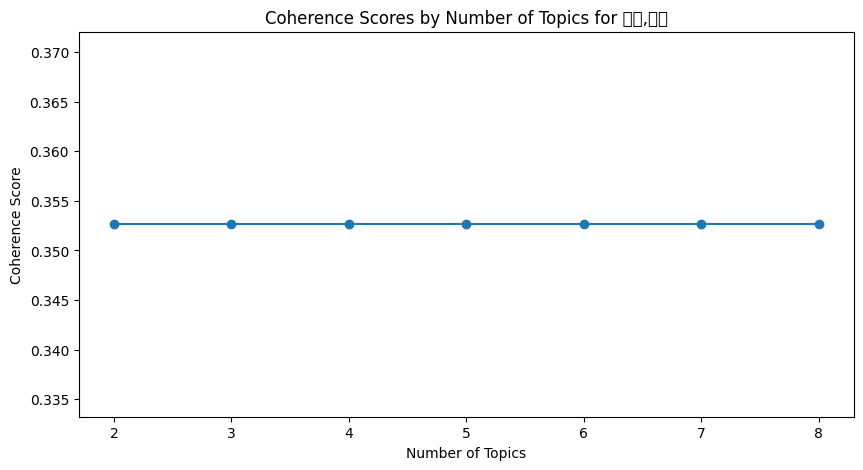

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48036 (\N{HANGUL SYLLABLE MYU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IP

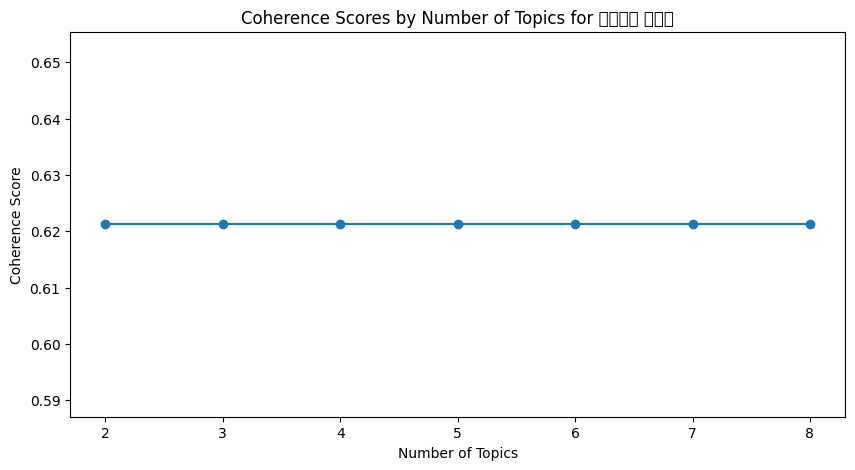

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52285 (\N{HANGUL SYLLABLE CANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


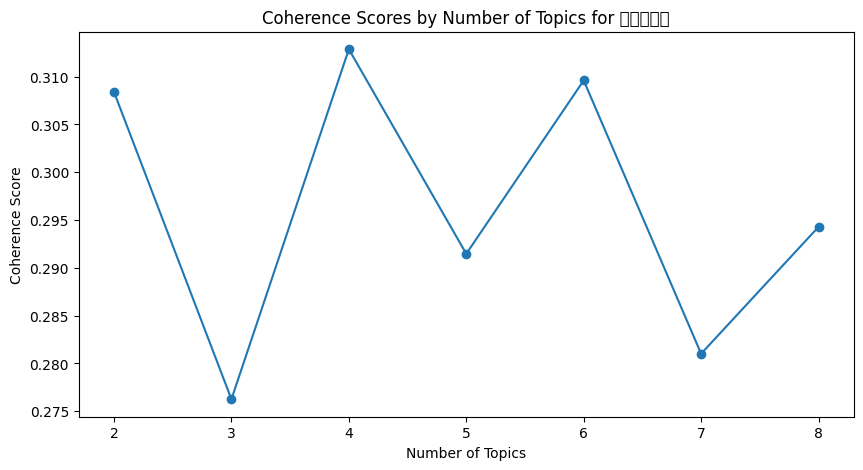

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


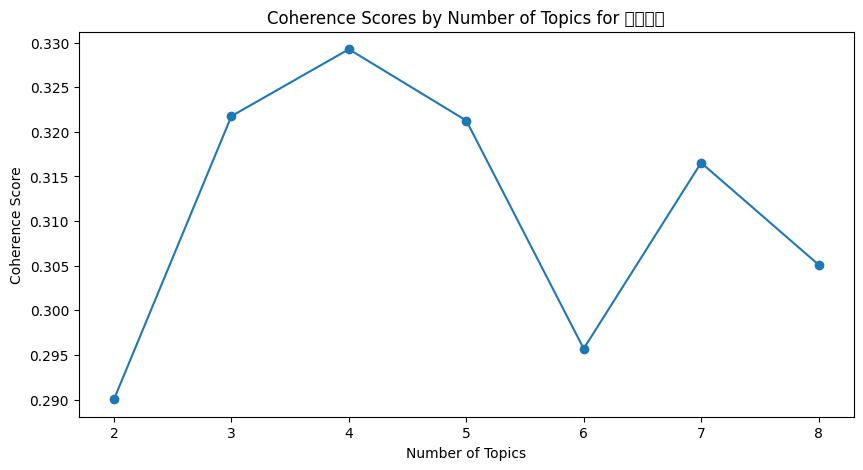

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47592 (\N{HANGUL SYLLABLE MAEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


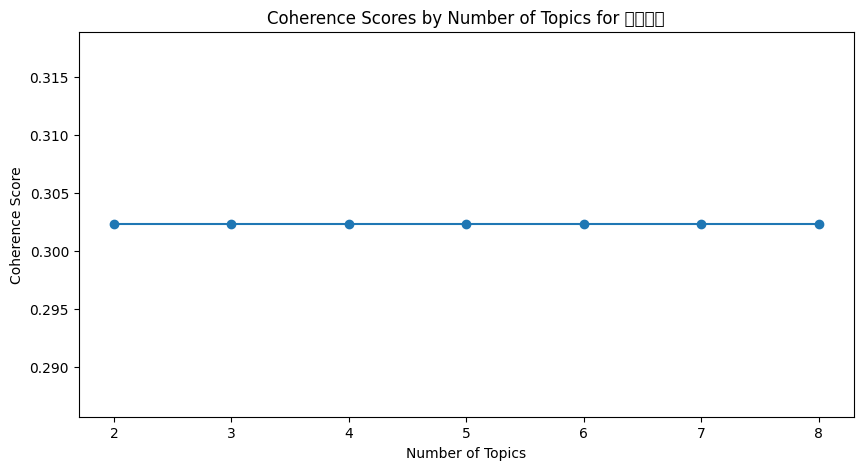

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46356 (\N{HANGUL SYLLABLE DI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


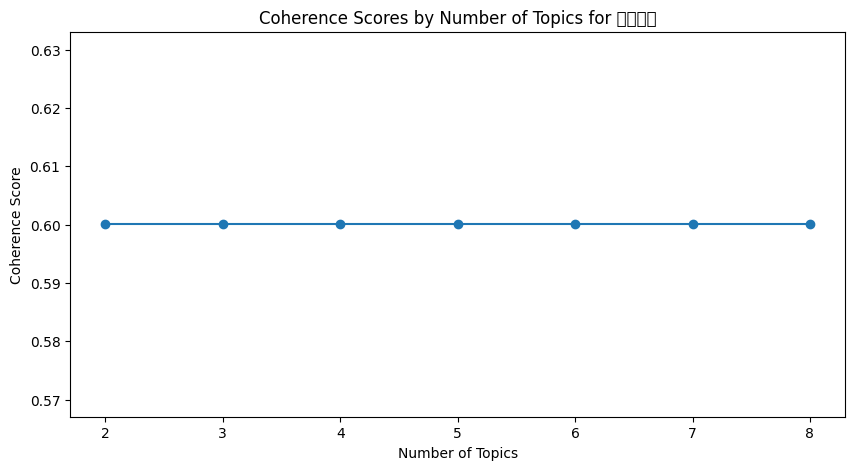

In [ ]:
import matplotlib.pyplot as plt

# 각 장르별로 일관성 점수 변화 시각화
for genre, result in optimal_topics_per_genre.items():
    coherence_values = result['coherence_values']
    topic_range = range(2, 9)  # 토픽 수 범위

    plt.figure(figsize=(10, 5))
    plt.plot(topic_range, coherence_values, marker='o')
    plt.title(f"Coherence Scores by Number of Topics for {genre}")
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence Score")
    plt.xticks(topic_range)
    plt.show()

#후에 라벨링할때 사용한 코드(시놉시스에 이러한 키워드가 포함되어있으면 1 아니면 0

In [ ]:
# Define your keyword list
keywords = {
    'Magic': ['마법', '마술'],
    'Friendship': ['친구', '우정'],
    'Family': ['가족', '엄마', '아빠', '동생'],
    'Music': ['음악', '기교', '노래'],
    'Genius': ['천재'],
    'Craftsmanship': ['기술', '장인', '혁명', '작곡가', '화가', '예술'],
    'Life': ['인생', '삶'],
    'Love': ['사랑', '결혼', '연애', '아름다운'],
    'War': ['전쟁', '싸움', '결투', '군인'],
    'Dreams': ['꿈'],
    'Human Relationships': ['관계', '연애', '친구'],
    'Emotions': ['감정', '마음', '울음', '감동', '아름다운'],
    'Conflict': ['갈등', '충돌'],
    'Social Problems': ['사회문제', '빈부격차', '현실', '돈', '가난한'],
    'Human Nature': ['인간', '본성'],
    'Memories': ['기억', '추억'],
    'Her': ['그녀', '여자', '아내'],
    'Humor': ['유머', '농담', '웃음'],
    'Challenge': ['도전', '시련', '모험', '여행', '시작'],
    'Men': ['남자', '남편', '그'],
    'Novel': ['명작', '소설', '원작']
}

# Create new columns in the DataFrame for each keyword category
for key, values in keywords.items():
    df[key] = df['시놉시스'].apply(lambda x: 1 if any(keyword in x for keyword in values) else 0)

# Display the updated DataFrame with the new columns
df.head()

,Unnamed: 0,공연코드,평점,리뷰수,인지도,장르,시놉시스,Magic,Friendship,Family,...,Emotions,Conflict,Social Problems,Human Nature,Memories,Her,Humor,Challenge,Men,Novel
0,0,PF317858,10.00,2,18,창작뮤지컬,런던 외곽에 위치한 낡고 오래된 레코드 샵. 주인 존은 오늘도 하루를 활기차게 시작...,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,PF422856,9.14,93,7,로맨스극,"마법의 초콜릿, 내몸을 돌려줘!! 숨 막히는 피지컬, 외모, 실력 뭐 하나 빠지지 ...",1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,PF423813,9.66,212,25,창작뮤지컬,김.종.욱 이름 석자 빼곤 아는 게 없다! '첫사랑 주식회사' 첫 고객의 '첫사랑'...,0,0,0,...,0,0,0,0,0,1,0,0,1,0
3,3,PF435409,9.40,71,7,코미디극,연극의 줄거리는 배달을 주제로 한 다양한 에피소드로 구성되어 있습니다. 배달원과 고...,0,0,0,...,0,1,0,0,0,1,1,0,1,0
4,4,PF435506,9.42,2335,15,코미디극,"연극 ""나의 PS 파트너""는 실수로 잘못 걸린 전화로 시작됩니다. 주인공 지성은 여...",0,1,0,...,1,0,1,0,0,1,1,1,1,0


In [ ]:
# Save the DataFrame to a CSV file with UTF-8 encoding
df.to_csv('processed_demo.csv', index=False, encoding='utf-8-sig')